--- Task 1: Dataset Exploration ---
Total Records: 1500

Sample Records:
                                    customer_message sentiment_label
0  I need information about the payment process. ...         neutral
1      I need information about the payment process.         neutral
2  The refund process was fast and convenient. I ...        positive
3  My refund is still pending and this experience...        negative
4   Please tell me how to update my account details.         neutral

Average Word Count: 12.72


C:\Users\Vivek Vishwakarma\AppData\Local\Temp\ipykernel_35036\4014493236.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment_label', data=df, palette='Set2')


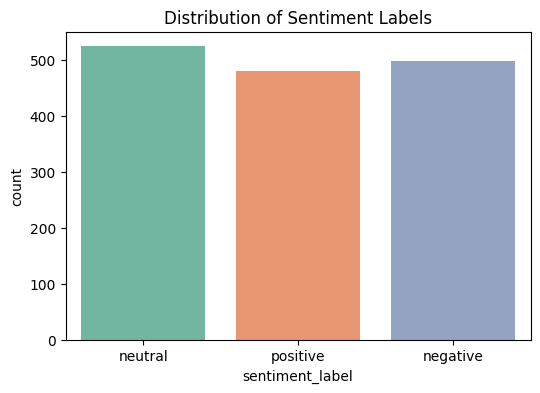

In [2]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout


# ==========================================
# Task 1: Dataset Understanding
# ==========================================
print("--- Task 1: Dataset Exploration ---")
df = pd.read_csv('customer_support_text_classification.csv')

print(f"Total Records: {len(df)}")
print("\nSample Records:")
print(df[['customer_message', 'sentiment_label']].head())

print(f"\nAverage Word Count: {df['word_count'].mean():.2f}")

# Plot Class Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='sentiment_label', data=df, palette='Set2')
plt.title('Distribution of Sentiment Labels')
plt.show()

In [3]:
# ==========================================
# Task 2: Text Preprocessing
# ==========================================
print("\n--- Task 2: Text Preprocessing ---")

def clean_text(text):
    text = text.lower() # Lowercase
    text = re.sub(r'[^\w\s]', '', text) # Remove punctuation & special characters
    return text

df['clean_message'] = df['customer_message'].apply(clean_text)

# Encode Labels (0: negative, 1: neutral, 2: positive)
label_mapping = {'negative': 0, 'neutral': 1, 'positive': 2}
df['label'] = df['sentiment_label'].map(label_mapping)

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(df['clean_message'], df['label'], test_size=0.2, random_state=42)
print("Text cleaned, lowercased, and split into train/test sets.")


--- Task 2: Text Preprocessing ---
Text cleaned, lowercased, and split into train/test sets.



--- Task 3 & 4: TF-IDF Vectorization & Baseline Model ---

Baseline Model (Logistic Regression) Evaluation:
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00       109
     neutral       1.00      1.00      1.00       104
    positive       1.00      1.00      1.00        87

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



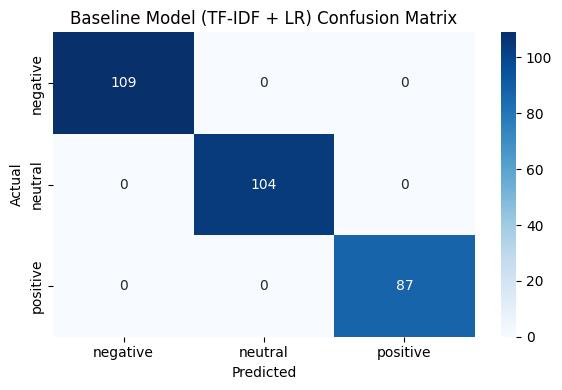

In [4]:
# ==========================================
# Task 3 & 4: Text Vectorization & Baseline Model
# ==========================================
print("\n--- Task 3 & 4: TF-IDF Vectorization & Baseline Model ---")

# 1. TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=3000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# 2. Baseline Model (Logistic Regression)
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)
y_pred_lr = lr_model.predict(X_test_tfidf)

print("\nBaseline Model (Logistic Regression) Evaluation:")
target_names = ['negative', 'neutral', 'positive']
print(classification_report(y_test, y_pred_lr, target_names=target_names))

# Save Baseline Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title('Baseline Model (TF-IDF + LR) Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('results/baseline_confusion_matrix.png')
plt.show()


--- Task 5: Sequence Modeling (LSTM) ---


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 50, 64)         │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 386,435 (1.47 MB)

 Trainable params: 386,435 (1.47 MB)

 Non-trainable params: 0 (0.00 B)


Training Bidirectional LSTM Model...
Epoch 1/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.5542 - loss: 1.0180 - val_accuracy: 0.8875 - val_loss: 0.7907
Epoch 2/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9229 - loss: 0.5093 - val_accuracy: 0.9708 - val_loss: 0.3035
Epoch 3/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9927 - loss: 0.1572 - val_accuracy: 1.0000 - val_loss: 0.0514
Epoch 4/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 0.0286 - val_accuracy: 1.0000 - val_loss: 0.0121
Epoch 5/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.0129 - val_accuracy: 1.0000 - val_loss: 0.0069
Epoch 6/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.0070 - val_accuracy: 1.0000 - val_loss: 0.0039
Epoch 7/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.0047 - val_accuracy: 1.0000 - val_loss: 0.0028
Epoch 8/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - l

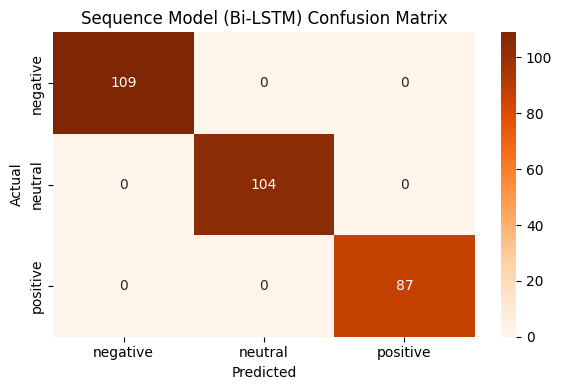

Process Complete! Images and sample predictions saved to 'results' folder.


In [8]:
from tensorflow.keras.layers import Input, Bidirectional

# ==========================================
# Task 5: Sequence Model (LSTM)
# ==========================================
print("\n--- Task 5: Sequence Modeling (LSTM) ---")

# 1. Tokenizer-based Sequences for LSTM (Using Keras Tokenizer)
vocab_size = 5000
max_length = 50 

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

# 'pre' padding ensures the actual words are at the end of the sequence!
X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=max_length, padding='pre')
X_test_seq = pad_sequences(tokenizer.texts_to_sequences(X_test), maxlen=max_length, padding='pre')

# 2. Build Upgraded Bidirectional LSTM Architecture
lstm_model = Sequential([
    Input(shape=(max_length,)), # <--- THIS explicitly tells Keras the size in advance!
    Embedding(input_dim=vocab_size, output_dim=64), 
    Bidirectional(LSTM(64, return_sequences=False)), 
    Dropout(0.3),
    Dense(3, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
lstm_model.summary()

# 3. Train LSTM Model (Bumped to 15 epochs to ensure it learns the patterns)
print("\nTraining Bidirectional LSTM Model...")
history = lstm_model.fit(X_train_seq, y_train, epochs=15, batch_size=32, validation_split=0.2, verbose=1)

# 4. Evaluate LSTM Model
print("\nEvaluating LSTM Model...")
y_pred_probs_lstm = lstm_model.predict(X_test_seq)
y_pred_lstm = np.argmax(y_pred_probs_lstm, axis=1)

print("\nUpgraded Bi-LSTM Model Evaluation:")
print(classification_report(y_test, y_pred_lstm, target_names=target_names))

# Save LSTM Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_lstm), annot=True, fmt='d', cmap='Oranges', xticklabels=target_names, yticklabels=target_names)
plt.title('Sequence Model (Bi-LSTM) Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('results/lstm_confusion_matrix.png')
plt.show()

# Export metrics for assignment requirements
with open('results/sample_predictions.txt', 'w') as f:
    f.write("Sample Predictions from Upgraded Bi-LSTM Model:\n")
    for i in range(5):
        actual = target_names[y_test.iloc[i]]
        pred = target_names[y_pred_lstm[i]]
        text = X_test.iloc[i]
        f.write(f"Text: {text}\nActual: {actual} | Predicted: {pred}\n\n")
print("Process Complete! Images and sample predictions saved to 'results' folder.")